Install Required Libraries

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn shap

Note: you may need to restart the kernel to use updated packages.


Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)

import shap

c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = pd.read_csv("bank.csv", sep=',')
# Basic data exploration
print("Shape of Dataset:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData types:")
print(df.info())
print("\nFirst 5 rows of dataset:")
print(df.head())

Shape of Dataset:
(11162, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null

Load Dataset

In [6]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [7]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [8]:
print(df["deposit"].value_counts())

deposit
no     5873
yes    5289
Name: count, dtype: int64


Target Variable Encoding

In [10]:
df['y'] = df['deposit'].map({'Yes': 1, 'No': 0})
X = df.drop('deposit', axis=1)
y = df['deposit']

In [11]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')
Numerical: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'y'],
      dtype='object')


In [12]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


F1 Score: 0.8134615384615385

Classification Report
              precision    recall  f1-score   support

          no       0.82      0.85      0.84      1175
         yes       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.83      2233
weighted avg       0.83      0.83      0.83      2233



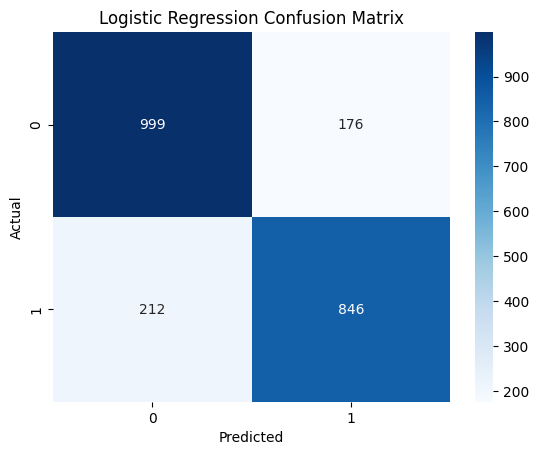

In [15]:
print("F1 Score:", f1_score(y_test, y_pred_lr, pos_label='yes'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

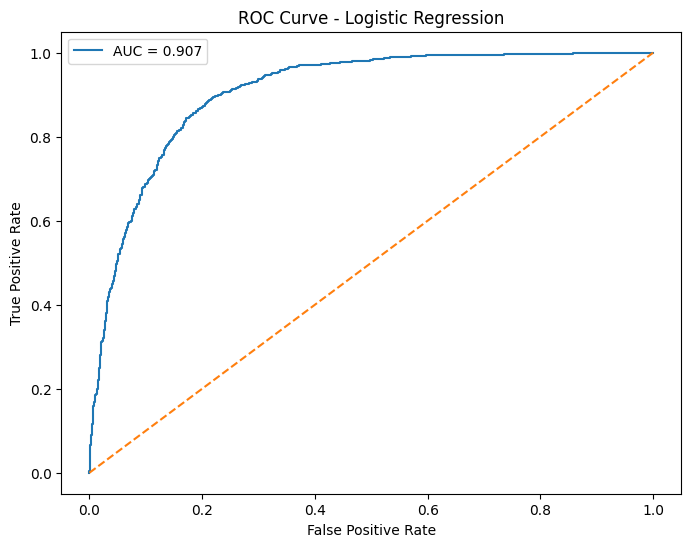

In [16]:
y_test_num = y_test.map({'no':0, 'yes':1})

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr, pos_label='yes')

auc = roc_auc_score(y_test_num, y_prob_lr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

In [18]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


F1 Score: 0.8596171376481313

Classification Report
              precision    recall  f1-score   support

          no       0.90      0.84      0.86      1175
         yes       0.83      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



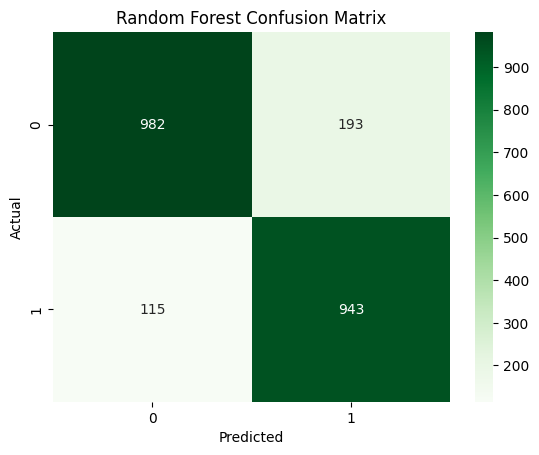

In [19]:
print("F1 Score:", f1_score(y_test, y_pred_rf, pos_label='yes'))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

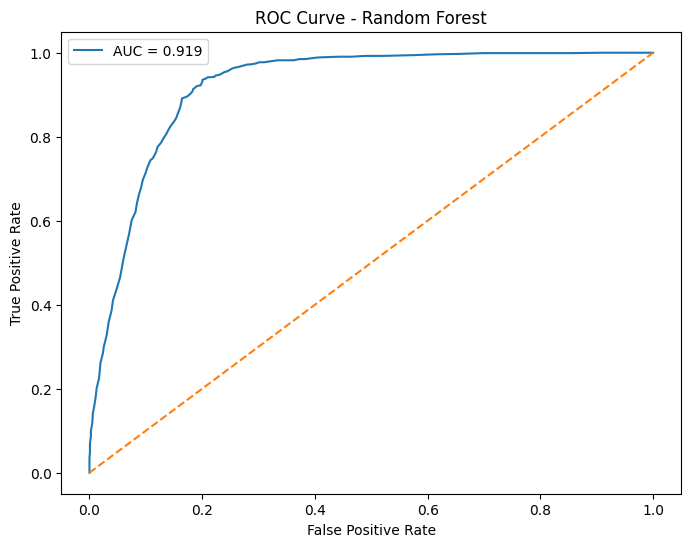

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf, pos_label='yes')
auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [21]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\shuma\anaconda3\envs\python_ml\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['y']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_processed)

In [ ]:
for i in range(5):

    print(f"\nPrediction {i+1}")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[1][i],
            base_values=explainer.expected_value[1],
            data=X_test_processed[i]
        )
    )

    plt.show()

In [ ]:
shap.summary_plot(
    shap_values[1],
    X_test_processed
)